# Week 4b — Solar Capacity-Factor Forecast

Same idea as `notebooks/09` (wind), but solar has a structurally different problem: on top of a weather-driven component (cloud cover, irradiance), it has a **hard deterministic ceiling** from solar geometry — exactly zero at night, a fixed maximum set by time-of-day/year and solar elevation angle, regardless of weather (PLAN.md Week 4b). `edf.features.generation.solar_elevation_deg` computes that ceiling directly from timestamp + location (a standard astronomical formula, no API/weather data needed), so the model gets an exact physical constraint as a feature, not just a correlate.

**Hypothesis:** that deterministic ceiling should make solar *more* predictable than wind, given a forecast — the model doesn't have to learn day/night from data, it's handed the answer directly as a feature.

Same TRAIN-on-ERA5 / honest-check-on-day-ahead-slice structure as wind and the demand ablation.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.models.baselines import previous_week_same_time
from edf.data.weather import DAY_AHEAD_ARCHIVE_START
from edf.evaluate import evaluate
from edf.models.forecast import train_lightgbm
from edf.features.generation import build_solar_feature_table, capacity_factor
from edf.tracking import log_model_run
from edf.models.tuning import tune_lightgbm, walk_forward_cv_folds
from edf.features.weather import build_weather_feature_table

pd.options.display.float_format = "{:.4f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")

2026/09/07 11:34:39 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/sidonio.silva/RiderProjects/Personal/energy_demand_forecast/.venv/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

solar_cf = capacity_factor(df["solar"], df["solar_capacity"])
solar_cf.loc[val_start:val_end].describe()

count   17568.0000
mean        0.0896
std         0.1392
min         0.0000
25%         0.0000
50%         0.0002
75%         0.1438
max         0.6534
dtype: float64

## Seasonal-naive capacity-factor baseline

In [3]:
naive_cf_val = previous_week_same_time(solar_cf).loc[val_start:val_end]
naive_mae = evaluate(solar_cf.loc[val_start:val_end], naive_cf_val)["mae"]
naive_mae

0.03833673368697902

## Tune + train on ERA5 (hindsight) weather

In [4]:
era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
X, y = build_solar_feature_table(df, era5)
X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
X_val, y_val = X.loc[val_start:val_end], y.loc[val_start:val_end]

folds = walk_forward_cv_folds(X_train.index)
t0 = time.time()
best_params, best_n, trials = tune_lightgbm(X_train, y_train, folds, n_trials=10)
tune_seconds = time.time() - t0
model = train_lightgbm(X_train, y_train, n_estimators=best_n, **best_params)
print(f"best={best_params}, n_estimators={best_n}, tune={tune_seconds:.0f}s")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000487 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3892
[LightGBM] [Info] Number of data points in the train set: 17568, number of used features: 18
[LightGBM] [Info] Start training from score 0.104395


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3893
[LightGBM] [Info] Number of data points in the train set: 35088, number of used features: 18
[LightGBM] [Info] Start training from score 0.101053


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3892
[LightGBM] [Info] Number of data points in the train set: 52608, number of used features: 18
[LightGBM] [Info] Start training from score 0.102223


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3892
[LightGBM] [Info] Number of data points in the train set: 17568, number of used features: 18
[LightGBM] [Info] Start training from score 0.104395


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3893
[LightGBM] [Info] Number of data points in the train set: 35088, number of used features: 18
[LightGBM] [Info] Start training from score 0.101053


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3892
[LightGBM] [Info] Number of data points in the train set: 17568, number of used features: 18
[LightGBM] [Info] Start training from score 0.104395


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000311 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3893
[LightGBM] [Info] Number of data points in the train set: 35088, number of used features: 18
[LightGBM] [Info] Start training from score 0.101053


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3892
[LightGBM] [Info] Number of data points in the train set: 52608, number of used features: 18
[LightGBM] [Info] Start training from score 0.102223


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3892
[LightGBM] [Info] Number of data points in the train set: 70128, number of used features: 18
[LightGBM] [Info] Start training from score 0.100912


best={'num_leaves': 15, 'min_child_samples': 20, 'learning_rate': 0.03}, n_estimators=136, tune=40s


## Own-merit evaluation

**`mape` will be `inf` here** — solar capacity factor is *exactly* zero at night, and `edf.evaluate.mape` divides by the actual value, so every nighttime row is a division by zero. This isn't a bug in the metric; it's `mape` being structurally unsuited to a target with real zeros, worse even than wind's near-zero-but-never-exactly-zero case in `notebooks/09`. MAE/RMSE/MASE are the only trustworthy numbers in this table.

In [5]:
preds_era5 = pd.Series(model.predict(X_val), index=X_val.index)
m_era5 = evaluate(y_val, preds_era5, seasonal_naive_mae=naive_mae)
pd.Series(m_era5)

mae                 0.0162
rmse                0.0297
mape                   inf
bias               -0.0046
p95_abs_error       0.0710
n               17568.0000
mase                0.4221
dtype: float64

## Finding: hypothesis confirmed — and the deterministic ceiling shows up directly in the fit

MAE 0.0162 vs. the seasonal-naive baseline's 0.0383 — a **57.7% reduction** (MASE 0.422), essentially the same relative gain as wind's 58%. But the *character* of the fit is different, visible in the one-week plot below: night-time zeros are captured exactly (no residual error at all when `solar_elevation_deg` is 0), and the daytime peaks track actual generation tightly, including day-to-day cloud variation (contrast with wind's notebook 09, where high-wind peaks were visibly underestimated). Confirms the stated hypothesis: the deterministic ceiling genuinely makes solar easier to fit well than wind, given a forecast.

## Honest check: genuine day-ahead weather at inference, `2024-03-07`-onward

In [6]:
day_ahead = build_weather_feature_table("open_meteo_day_ahead", df.index, raw_dir=WEATHER_RAW_DIR)
X_day_ahead, y_day_ahead = build_solar_feature_table(df, day_ahead)

slice_start = str(DAY_AHEAD_ARCHIVE_START.date())
y_slice = y_val.loc[slice_start:val_end]
naive_mae_slice = evaluate(
    solar_cf.loc[slice_start:val_end], naive_cf_val.loc[slice_start:val_end]
)["mae"]

preds_era5_slice = preds_era5.loc[slice_start:val_end]
X_da_slice = X_day_ahead.loc[slice_start:val_end]
preds_day_ahead_slice = pd.Series(model.predict(X_da_slice), index=X_da_slice.index)

m_era5_slice = evaluate(y_slice, preds_era5_slice, seasonal_naive_mae=naive_mae_slice)
m_day_ahead_slice = evaluate(
    solar_cf.loc[preds_day_ahead_slice.index], preds_day_ahead_slice, seasonal_naive_mae=naive_mae_slice
)

honest = pd.DataFrame({"era5": m_era5_slice, "day_ahead": m_day_ahead_slice}).T
print(f"Slice: {slice_start} to {val_end}, n={len(y_slice)}")
honest

Slice: 2024-03-07 to 2024-12-31, n=14400


,mae,rmse,mape,bias,p95_abs_error,n,mase
era5,0.0173,0.0313,inf,-0.0054,0.0749,14400.0000,0.4222
day_ahead,0.0193,0.0351,inf,-0.0126,0.0860,14400.0000,0.4697


## Finding: this time, day-ahead genuinely underperforms ERA5 — as theory predicts

Unlike both the demand-model ablation and the wind model — where the day-ahead-fed evaluation scored marginally *better* than ERA5-fed, in both cases traced to noise or a coincidental bias cancellation — here day-ahead is clearly **worse**: MASE 0.470 vs. ERA5's 0.422, an 11.3% relative degradation, with a larger negative bias too (-0.013 vs. -0.005). This is the expected direction (more lead time → more error), and it's a useful cross-check on the other two "surprising" results: it confirms those weren't a bug in the evaluation methodology, since the same method here gives the textbook answer. A believable physical reason for solar specifically being harder at day-ahead lead time: cloud formation is much more short-timescale and chaotic than large-scale wind patterns, so a 24h-ahead cloud-cover/irradiance forecast has more genuine skill to lose than a 24h-ahead wind-speed forecast does. **Still, 0.422 → 0.470 is a small gap next to the seasonal-naive baseline's 1.0 — most of the gain survives, it's just not "almost all of it" the way it was for wind and demand.**

## Feature importance

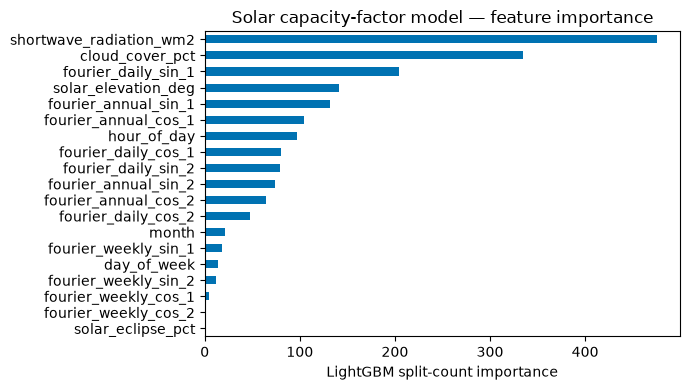

In [7]:
importance = pd.Series(model.feature_importances_, index=model.feature_name_).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
importance.iloc[::-1].plot.barh(ax=ax, color="#0072B2")
ax.set_title("Solar capacity-factor model — feature importance")
ax.set_xlabel("LightGBM split-count importance")
fig.tight_layout()

## Plot: actual vs. predicted solar capacity factor, one week

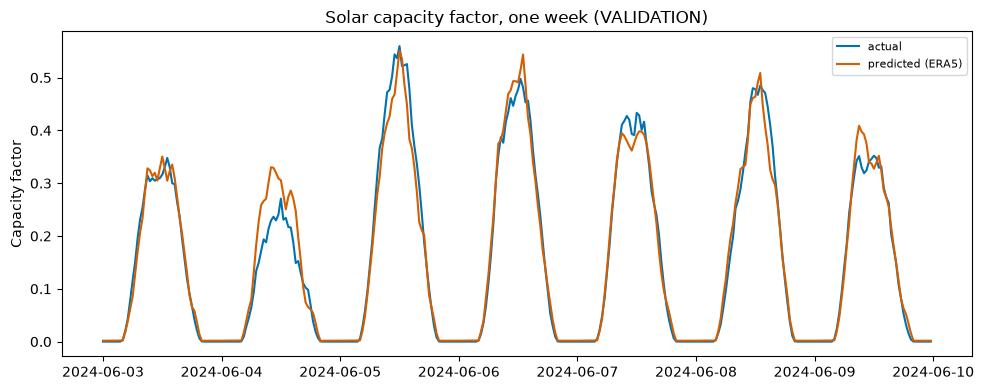

In [8]:
window = slice("2024-06-03", "2024-06-09")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_val.loc[window].index, y_val.loc[window], label="actual", color="#0072B2")
ax.plot(preds_era5.loc[window].index, preds_era5.loc[window], label="predicted (ERA5)", color="#D55E00")
ax.set_title("Solar capacity factor, one week (VALIDATION)")
ax.set_ylabel("Capacity factor")
ax.legend(fontsize=8)
fig.tight_layout()

## Note: `mape` is `inf` here, not a display glitch

Solar capacity factor is *exactly* zero for roughly half of every day (night), and `edf.evaluate.mape` divides by the actual value — every nighttime row is a literal division by zero. This is worse than wind's case (near-zero but never exactly zero), confirming `mape` simply shouldn't be used for this target. Not a new finding so much as a concrete illustration of a metric-selection pitfall worth remembering for Week 5's probabilistic work, where other zero-heavy targets could hit the same issue.

## Log to MLflow

In [9]:
log_model_run(
    horizon_name="1d",
    horizon_periods=config.HORIZONS["1d"],
    model_name="lightgbm",
    fold_metrics=pd.DataFrame([m_era5], index=pd.Index([2024], name="year")),
    extra_tags={"strategy": "direct", "tuned": "true", "target": "solar_capacity_factor"},
    extra_params={**best_params, "n_estimators": best_n},
    extra_metrics={"tune_seconds": tune_seconds},
)
print("Logged solar capacity-factor run to MLflow (forecast-1d experiment)")

Logged solar capacity-factor run to MLflow (forecast-1d experiment)
